# Лекция. Визуализация в maplotlib

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## § 1. Минимализм

Библиотека matplotlib — это патриарх визуализации в python, она появилась еще в 2003 году. Её создатель, Джон Хантер, хотел, чтобы в Python можно было строить графики так же просто, как в системе MATLAB (отсюда и название). С тех пор появилось много других библиотек, но matplotlib остается фундаментом: почти все остальные инструменты (например, Seaborn или встроенные графики в Pandas) построены «поверх» него.

Главная сила matplotlib — в его универсальности. На нём можно нарисовать абсолютно всё: от простого графика до сложнейшей интерактивной научной схемы. Это стандарт де-факто: если вы умеете работать с matplotlib, вы поймете любую другую библиотеку визуализации.

Мы будем использовать модуль `pyplot`. Это набор функций, которые позволяют создавать графики быстро, буквально одной командой. В профессиональной среде его принято импортировать под коротким псевдонимом `plt`.

### Простейшие графики

Прежде чем переходить к большим данным, давайте посмотрим на самый простой пример. Допустим, у нас есть обычная  последовательность чисел или, в терминологии python, — список. Пусть это, например, квадраты натурального ряда, и мы хотим их визуализировать.

Исполняем команду:

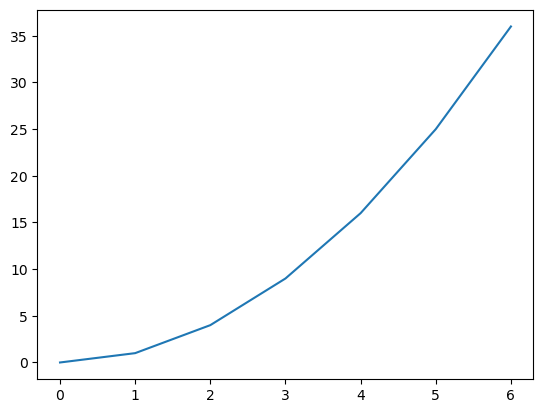

In [2]:
plt.plot([0, 1, 4, 9, 16, 25, 36])

Что-то нарисовалось. Но, честно говоря, это не совсем то, что мы ожидали увидеть: должна ведь получиться правая ветвь параболы, а, если мы хоть что-то помним из школьной математики, парабола выглядит как-то не так. Похоже, но не так. Какая-то она слишком пологая. И вообще, это не кривая, а ломаная.

Ок. Давайте подадим на вход методу `plot` не список из семи элементов, а два массива, в которых по сто элементов (в этом синтаксисе первый массив указывает на горизонтальную координату, второй — на вертикальную):

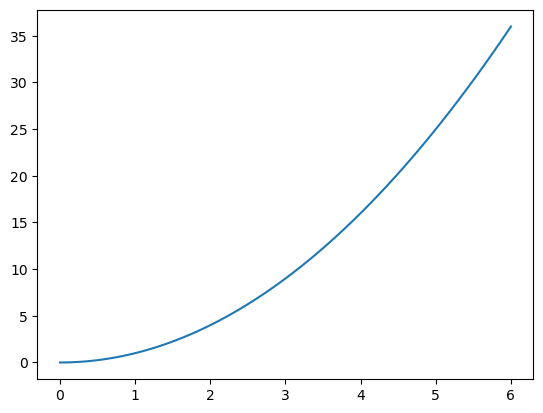

In [3]:
plt.plot(np.linspace(0, 6, 100), (np.linspace(0, 6, 100))**2)

То, что мы видим, стало гладким (хотя, на самом деле, это тоже ломаная, только с очень короткими звеньями). Но характер поведения кривой не изменился, кривая по-прежнему не очень похожа на параболу.

В чем дело? Что не так?

Не так то, что единицы масштаба по горизонтали и по вертикали не соответствуют друг другу. А это, в свою очередь, является следствием того, что мы не порудились настроить параметры вывода нашей картинки, а применили буквальный иллюстративный минимализм: написали одну строчку кода и нажали Shift+Enter.

#### Для чего это нужно

Как ни странно, на этапе проведения исследований этот незамысловатый приём оказывается весьма полезен. Если мы, например, в цикле при помощи методе `append` заполнили какой-то список, в котором тысяча позиций, и нас интересует характер  поведения этого списка при росте счётчика (возрастание, убывание, есть ли максимумы и т. д.), то нам вполне достаточно будет одной строчки кода и такой примитивной картинки, для того, чтобы выяснить все, что нам нужно.

При изучении более сложных данных, организованных в виде датафреймов, минималистичные приемы визуализации тоже играют далеко не последнюю (если не сказать — ведущую) роль.

### Данные для анализа

Возьмем данные о проведении A/B тестирования рекомендательной системы на сайте интернет-магазина:

In [3]:
df = pd.read_csv('data/df_ab.csv')
df

,user id,group,device type,session count,pages per session,time on site total,purchase count,total spent,avg basket size,conversion,is returning,category preference
0,375,control,desktop,8,2.5,9.0,4,2017.78,504.45,0.500,True,clothing
1,100,control,desktop,5,7.3,31.5,8,1999.64,249.96,1.600,True,home
2,171,experiment,mobile,14,7.8,29.9,2,3301.23,1650.61,0.143,True,clothing
3,416,control,tablet,8,4.8,18.2,5,1791.64,358.33,0.625,False,electronics
4,236,experiment,mobile,13,6.4,48.0,7,3825.48,546.50,0.538,True,home
...,...,...,...,...,...,...,...,...,...,...,...,...
495,409,experiment,mobile,12,6.8,40.8,5,3406.47,681.29,0.417,True,clothing
496,352,control,tablet,10,3.8,12.4,4,2189.06,547.26,0.400,True,electronics
497,257,control,mobile,6,6.2,15.0,3,2173.23,724.41,0.500,True,home
498,46,experiment,desktop,16,7.3,46.5,4,4504.24,1126.06,0.250,False,books


#### Контекст

Результаты A/B-тестирования новой рекомендательной системы на сайте интернет-магазина:


- user_id — ID пользователя (int),
- group — группа A/B-теста (str),
- session count — количество сессий за 2 недели (int),
- pages per session — среднее количество страниц за сессию (float),
- time on site total — общее время на сайте в минутах (float),
- purchase count — количество покупок (int),
- total spent — сумма покупок в рублях (float),
- avg basket size — средний чек = total spent / purchase count (float),
- device type — тип устройства (str),
- is returning — возвращался ли пользователь на сайт после первого визита (bool),
- conversion — конверсия = purchase count / session count (float), 
- category preference — категория, в которой совершено больше всего покупок (str).

### Гистограмма (Histogram)

Самый частый вопрос аналитика: «Как распределены наши данные?». Например, сколько люди тратят? Ответ — вот сколько:

(array([ 1.,  0.,  0.,  1.,  2.,  2., 10., 11., 30., 19., 40., 57., 50.,
        45., 27., 42., 27., 20., 22., 13., 13., 11., 12., 10., 11., 10.,
         7.,  2.,  2.,  3.]),
 array([ 231.04 ,  382.178,  533.316,  684.454,  835.592,  986.73 ,
        1137.868, 1289.006, 1440.144, 1591.282, 1742.42 , 1893.558,
        2044.696, 2195.834, 2346.972, 2498.11 , 2649.248, 2800.386,
        2951.524, 3102.662, 3253.8  , 3404.938, 3556.076, 3707.214,
        3858.352, 4009.49 , 4160.628, 4311.766, 4462.904, 4614.042,
        4765.18 ]),
 <BarContainer object of 30 artists>)

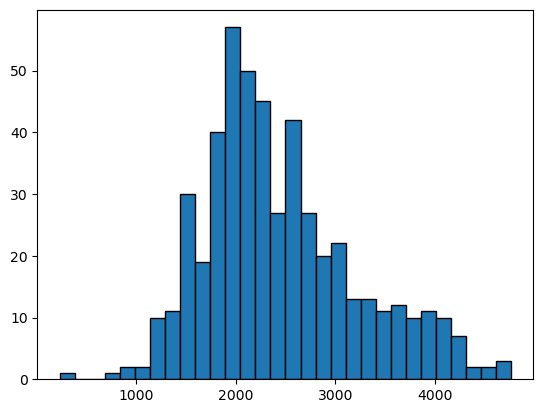

In [5]:
plt.hist(df['total spent'], bins=30, edgecolor='black')

Если вы заметили, мы опять написали одну строчку кода. Правда, при этом получили кучу мусора, но это не так важно, если нас действительно интересует ответ на вопрос, сколько люди тратят. Теперь мы знаем, что обычно они тратят где-то от 1.5 до 3.2 тысяч рублей.

А сколько времени люди проводят на сайте? Вот сколько:

(array([ 4.,  3.,  6.,  5.,  8.,  8., 13., 18., 16., 33., 19., 24., 29.,
        25., 28., 31., 29., 36., 33., 22., 19., 22., 14., 16., 13.,  8.,
         7.,  6.,  2.,  3.]),
 array([ 5.        ,  7.14333333,  9.28666667, 11.43      , 13.57333333,
        15.71666667, 17.86      , 20.00333333, 22.14666667, 24.29      ,
        26.43333333, 28.57666667, 30.72      , 32.86333333, 35.00666667,
        37.15      , 39.29333333, 41.43666667, 43.58      , 45.72333333,
        47.86666667, 50.01      , 52.15333333, 54.29666667, 56.44      ,
        58.58333333, 60.72666667, 62.87      , 65.01333333, 67.15666667,
        69.3       ]),
 <BarContainer object of 30 artists>)

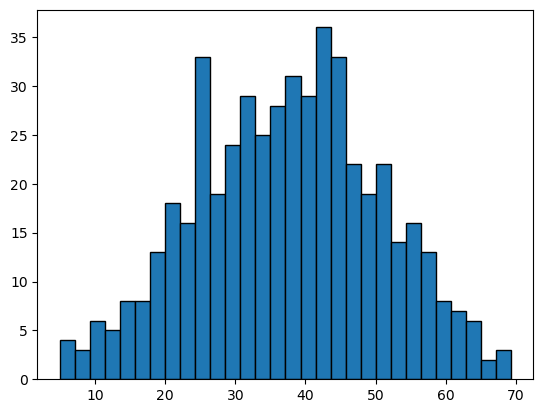

In [6]:
plt.hist(df['time on site total'], bins=30, edgecolor='black')

Опять куча мусора, но зато всего одна строчка, и мы знаем ответ: примерно от десяти минут до часа. Конечно, это очень примерно. Но для того и применяют визуализации в исследованиях, чтобы очень быстро получать очень приблизительные ответы.

#### Для чего это нужно

Гистограмма незаменима для анализа непрерывных величин (деньги, время, возраст). Она разбивает диапазон (например, от 0 до 15 000 руб.) на «корзины» (bins) и показывает, сколько наблюдений попало в каждую корзину (например, по первой гисторамме мы сразу видим, что людей большинство тратят мало, а богатых клиентов — единицы).

### Диаграмма рассеяния (Scatter plot)

А есть ли связь между временем на сайте и чеком?

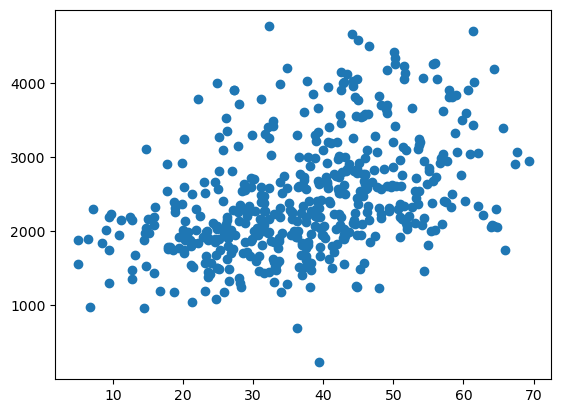

In [7]:
plt.scatter(df['time on site total'], df['total spent'])

Ответ — а черт его знает. Вроде бы, какая-то общая тенеденция есть, но, вместе с тем, она какая-то неочевидная. Так что быстрый ответ — связь есть, не не ярко выраженная. И это снова при помощи одной строчки.

А есть ли связь между числом страниц, которые человек обычно просматривает, и времением, которое он проводит на самйте? Давайте посмотрим:

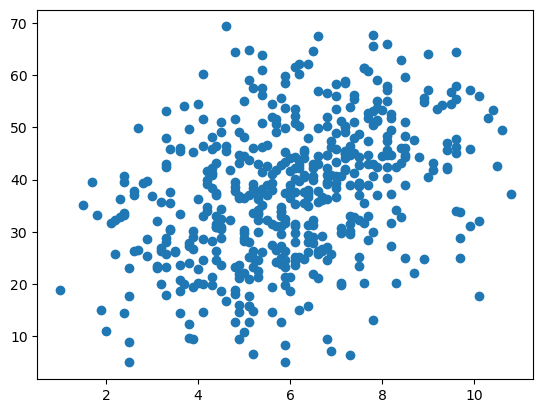

In [8]:
plt.scatter(df['pages per session'], df['time on site total'])

Ну хотя бы тут ответ виден. Связи нет никакой, это очевидно.

#### Для чего это нужно

Диаграмма рассеяния используется для поиска взаимосвязи между двумя числовыми признаками. Каждая точка — это отдельное наблюдение. Если точки выстраиваются в вытянутое облако — связь есть. Если они разбросаны хаотично — связи нет.

### Коробчатая диаграмма (Boxplot)

Давайте сравним траты в группах control и experiment. Для этого нам сначала нужно провести локализации по булевым маскам:

In [9]:
control_data = df[df['group'] == 'control']['total spent']
exp_data = df[df['group'] == 'experiment']['total spent']

А потом снова написать одну строчку:

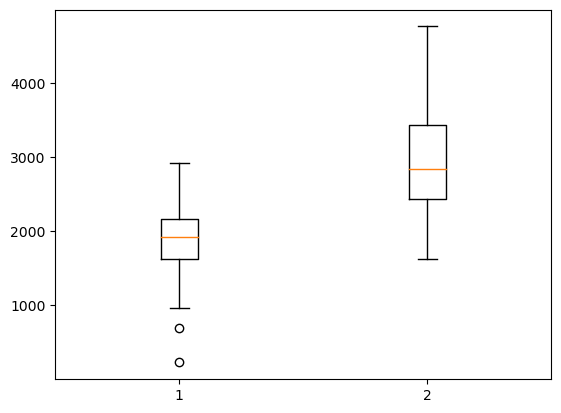

In [10]:
plt.boxplot([control_data, exp_data])
plt.show()

Снова куча мусора. Зато мы сразу видим, что смещение среднего чека в экспериментальной группе (второй ящик) относительно контрольной группы (1 ящик), безусловно, есть. Другой вопрос — является ли оно статистически значимым, но, так или иначе, у нас уже есть  разумная гипотеза, которую можно подтвердить или опровергнуть. А самое главное — мы получили ее очень быстро. 

#### Для чего это нужно

Boxplot («ящик с усами») — лучший друг статистика. Он позволяет сравнивать распределения в разных группах. Линия внутри ящика — это медиана (середина). Сам ящик — это основная масса пользователей. Точки за «усами» — аномалии (выбросы). Если один ящик заметно выше другого — значит, в этой группе люди действительно платят больше.

>#### Задание
Попробуйте самостоятельно найти какие-нибудь закономерности в данных при помощие методов `hist`, `scatter` или `boxplot`.

### Что дальше?

Итак, мы увидели, что matplotlib всеяден: он легко принимает и списки, и массивы и столбцы из датафрейма (серии). Мы научились строить базу: смотреть на распределения, искать зависимости и сравнивать группы. В подавляющем большинстве случаем для проведения исследования этого будет достаточно.

Но жизнь, к сожалению, устроена так, что результаты исследований всегда нужно куда-то передавать (если вы, конечно, не знамаетесь этим просто так, ради собственного удовольствия): в отчет начальству, в презентацию или в научную статью. А как вы, наверное, заметили, наши графики выглядят скудными и неопрятными: непонятно, где какие оси, нет заголовков, нет подписей групп. И вообще, это пока не иллюстрации, а инструменты исследования.

Дальше мы будем использовать matplotlib интеллигентно: мы научимся управлять нашими иллюстрациями. Потому что matplotlib — это мощная вещь. С его помощью можно нарисовать все что угодно. 

## § 2. Холсты и оси

Когда мы в первом параграфе писали plt.hist или plt.scatter, мы не задумывались, на чем именно мы рисуем. Просто вызывали команду — и график появлялся. Это похоже на то, как если бы вы взяли кисть, макнули в краску и взмахнули в воздухе: краска куда-то полетела (неизвестно, куда), но после этого на стене вдруг проявился рисунок в красивой рамочке. Понятно, что никакой магии в этом нет. Просто в очередной раз умная питоновская библиотека поработала за нас под капотом.

Для простых экспериментов это весьма удобно. Но как только мы захотим:

- расположить несколько графиков рядом,
- изменить размер и пропорции нашей картинки,
- подписать оси не на глаз, а с точностью до пикселя,
- сохранить график в файл с высоким разрешением,

— нам придётся познакомиться с двумя главными объектами matplotlib: `figure` и `axes`.

### Figure — это холст

Объект `figure` (фигура) — это внешняя оболочка всего изображения. Это что-то типа листа бумаги, на котором мы будем что-то рисовать. Размер этого листа, его цвет фона, разрешение в пикселях — всё это задаётся на уровне работы с `figure`.

При вызове этого метода ничего не происходит. Точнее, возвращается объект, но мы видим лишь вот что:

In [11]:
plt.figure()
plt.show()

<Figure size 640x480 with 0 Axes>

Метод `figure` создал объект, у которого есть ширина и высота, так как картинка — это всегда прямоугольник (даже если это кружок, то это кружок, вписанный в квадрат). Это холст. По умлочанию ширина хлоста равна 640, а высота — 480 пикселям.

А то такое метод `show`? Проще всего считать, что это закрывающая логическая скобка. То есть, мы открыли код картинки методом `figure` и закрыли методом `show`. Как правило, при его отсутствии ничего критического не происходит, но возможны и исключения: например, если рисовать картинки в цикле, то код с незакрытым `show`, отобразит все вообще не так, как мы ожидали (и, кстати, мусор, который появлялся при выводе на экран простейших команд в предыдущем параграфе, появлялся именно из-за незакрытого метода `show`).

>#### Задание
Попробуйте закрыть какой-нибудь код выше методом `show`. Вы увидите, что получится гораздо симпатичнее.

Мы можем изменить размеры и пропорции холста при помощи атрибута `figsize`, значением которого служит кортеж двух чисел, означающих ширину и высоту картинки в дюймах:

In [12]:
plt.figure(figsize=(9, 4))
plt.show()

<Figure size 900x400 with 0 Axes>

Обратите внимание, что размер холста изменился, но это не 9 на 4, как мы могли бы ожидать, а 900 на 100. Вывод метода `figure` всегда возвращает размеры в пикселях, а не в дюймах, и итоговые размеры получаются за счет еще одного параметра холста: его разрешения, или dpi (dots per inch — точек на дюйм). По умолчанию атрибут `dpi=100` (поэтому и получается размер 900 на 400), но его можно изменить. Например, для изображений, от которых потребуется высокое полиграфическое качество, можно указать:

In [13]:
plt.figure(figsize=(9, 4), dpi=300)
plt.show()

<Figure size 2700x1200 with 0 Axes>

При этом физический размер холста на экране не изменится: на экране холст по-прежнему будет занимать прямоугольник 9 на 4 дюйма. Изменится детализация изображения, так как на каждый дюйм будет приходиться более число пикселей.

Если покопаться в спецификации matplotlib, можно докопаться до настроек внешнего вида, при помощи которых можно настроить практически все. Например, ниже мы указали цвет подложки нашего холста (светло-желтый), цвет границы холста (синий) и толщину стандартной линии (2px).

In [14]:
plt.figure(figsize=(9, 4), facecolor='lightyellow', edgecolor='blue', linewidth=2)
plt.show()

<Figure size 900x400 with 0 Axes>

Управлять параметрами внешнего вида крайне не рекомендуется, кроме тех случаев, когда вы точно знаете, зачем вам это нужно. Стандартные цветовые палитры, как правило (а если быть честным перед самим собой, то всегда) гораздо более эстетичны по сравнению с любой пользовательской настройкой. 

Хорошо, что мы по-прежнему не видим на экране никакого объекта, но попробуйте вписать в код выше `plt.plot([1, 2, 3])` — и вы ужаснетесь увиденному!

Итак, метод `figure` сам по себе ничего не делает: он создает холст, то есть — возвращает набор инструкций, как именно должна выглядеть картинка, каковы должны быть ее размеры и пропорции, и какое у нее разрешение (в этом смысле он чем-то напоминает метод `groupby`, который тоже ничего не делает, но задает инструкцию по группировке).

### Что внутри figure

Объект `figure` может быть пустым (как это было выше), а может содержать внутри себя множество областей для рисования — осей `axes`.

Заметим, что мы уже встречались с атрибутом `axis`, который указывал направления для вычислений (`axis=0` — по столбцам, а `axis=1` — по строкам). Но сейчас, не смотря на терминологическое сходство, мы видим совершенно другой объект: `axes`. В английском языке axis означает ось (в единственном числе), а axes — оси (во множественном числе). Так вот, объект `axes` означает пару осей: горизонтальную и вертикальную, относительно которых рисуется график в `matplotlib`. И вообще, правильнее было бы говорить о системе координат, а не о паре осей (тогда не возникало бы терминологической путаницы), но, как это часто бывает — «так исторически сложилось», в силу чего, и то, и другое называется осями.

Вот как это выглядит в коде, если мы делаем всё явно и без магии:

<Axes: >

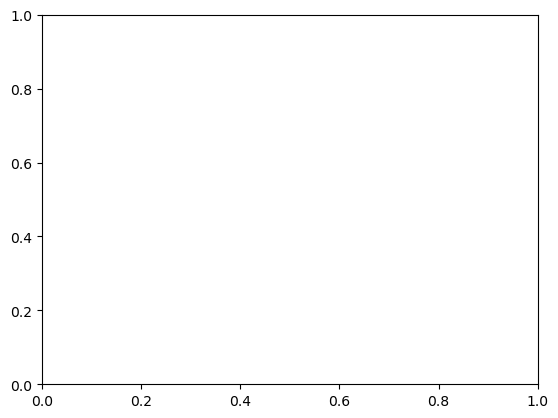

In [15]:
plt.figure().add_subplot()

Обратите внимание, что снова выскакивает мусор (`<Axes: >`), но на этот раз, это «полезный» мусор: он объясняет нам, что то, что получилось в результате, является объектом `axes` (по-русски говоря, координатной системой). Вы будете смеяться, но то, что получилось в результате, уже является картинкой, её можно  сохранить и посмотреть на неё в графическом редакторе. Правда, на ней ещё ничего нет: это просто координатная система без единой нанесённой на неё точки.

Магия начинается, когда мы переходим к методу `subplots`, который одновременно создаёт холст `figure` и целую сетку координатных систем `axes`. Это самый удобный способ организовать несколько графиков в рамках одного окна (он, как всегда, прячет под капот всю грязную работу). 

Двайте посмотрим:

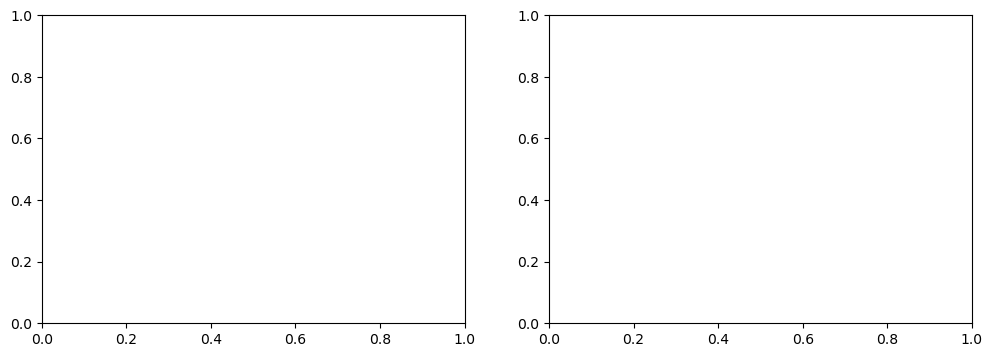

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
plt.show()

Логика атрибутов `nrows` и `ncols` очевидна: они указывают число строк и столбцов в сетке координатных систем, а атрибут `figsize` нам уже известен. То есть в данном случае мы разместили две координатные системы рядом в одном горизонтальном ряду.

Или еще один вариант:

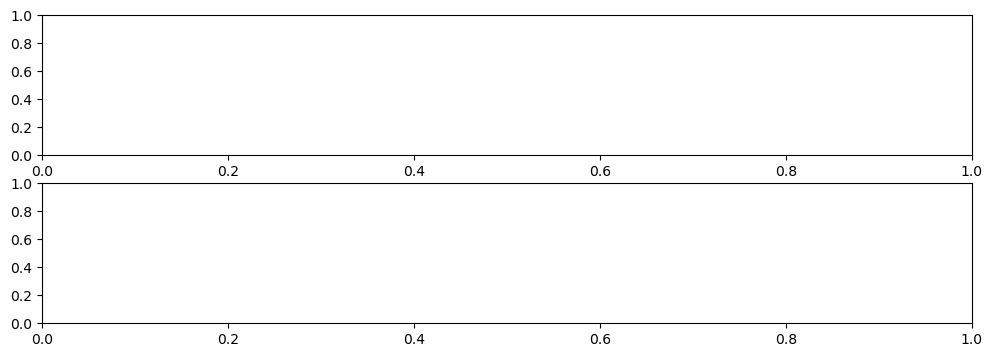

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 4))
plt.show()

Получились две координатные системы в одном вертикальном ряду. Дальнейшее понятно:

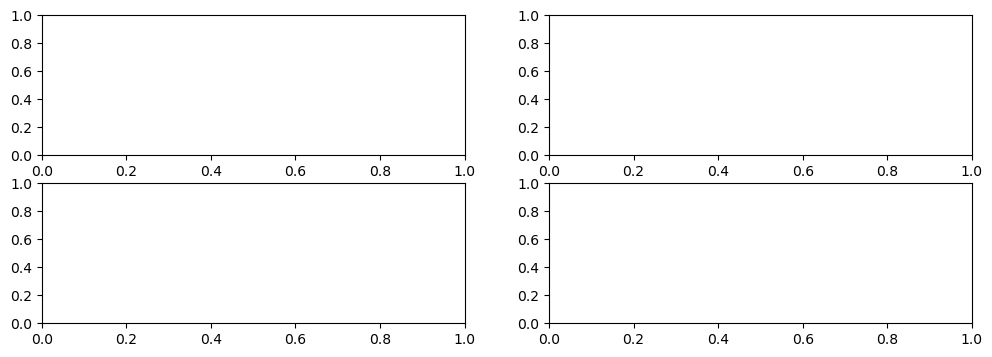

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 4))
plt.show()

Давайте посмотрим на значение переменной `fig`:

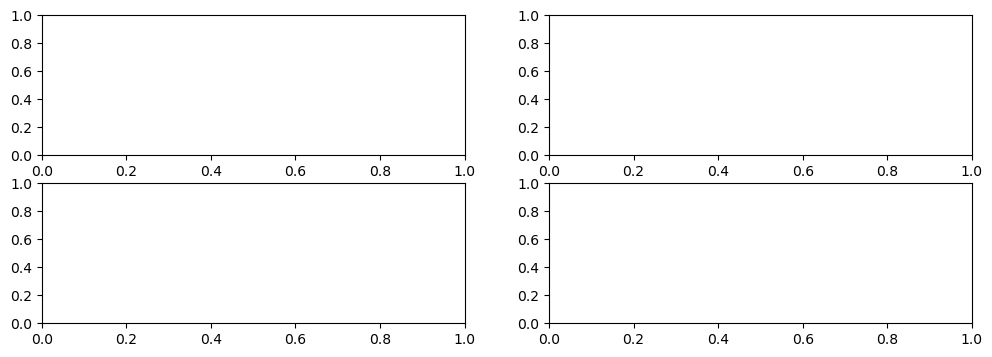

In [19]:
display(fig)

Мы видим буквально тот холст, который отображался после команды `show`.

Но если вывести переменную `ax`, то мы увидим лишь структуру сетки координатных систем:

In [20]:
display(ax)

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

В даном случае она представляет собой двумерный массив. Можно обратиться к какому-нибудь его элементу:

In [21]:
ax[0][1]

<Axes: >

Но это нам тоже ничего не даст. Мы видим, что это объект типа `axes`, но самого объекта (координатной системы) мы не видим. Важный вывод: просмотреть можно только холст целиком.

>#### Задание
Выведите на экран все возможные равномерные сетки от 1 на 1 до 5 на 5, используя для этого вложенный цикл.

### Краткий вывод о пути джедая и синтаксическом сахаре

Итак, `figure` — это контейнер, причём, он может существовать без `axes`. А `axes` без `figure` — не может (подобно тому как `agg` без `groupby` не имеет смысла). Поэтому `figure` находится выше в иерархии по отношению в `axes` (подобно тому как `groupby` выше, чем `agg`). Что же касается метода `subplots`, то это просто функция-конструктор, которая собирает нам готовую конструкцию. Внутри неё `figure` создаётся первой, а потом на неё крепится `axes`.

Если использовать простейшие синтаксические конструкции, (то, что выше, на лекции по группировкам, мы называли сахаром), то для проведения исследований, картинки рисовать совсем несложно. Например:

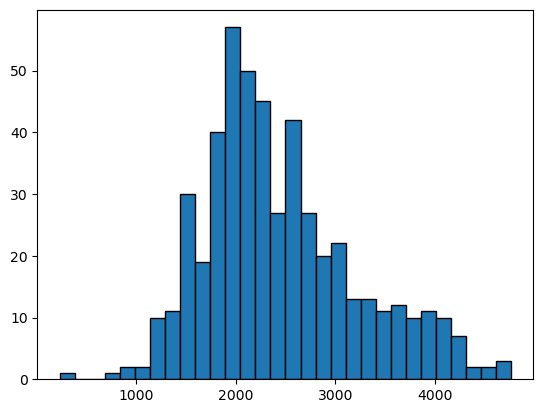

In [22]:
plt.hist(df['total spent'], bins=30, edgecolor='black')
plt.show()

Но для получения отчетности (особенно для презентаций) истинный датасайентист всегда идет по пути джедая, используя `figure`, `axes` и `subplots`, даже если ему нужно нарисовать всего одну картинку:

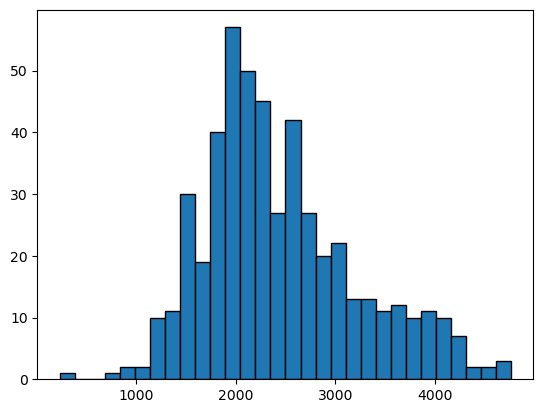

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(df['total spent'], bins=30, edgecolor='black')
plt.show()

Ну ладно. Почти всегда.

## § 3. Делаем красиво

В предыдущем параграфе мы научились создавать холст и координатные системы. Но графики получались так себе: нвыразительными и скучными. Настало время это исправить.


Мы пойдем по пути джедая: мы будем явно работать с `figure` и `axes`. Даже если нам будет нужен всего один график.

### Заголовки и подписи 

График без подписей осей и заголовка — это цветные каракули. Читатель должен с первого взгляда понять: что там идет по оси X, что по Y, о чём вообще график. Подписи — это минимальный уровень вежливости по отношению к читателю (или к зрителю вашей  презентации).

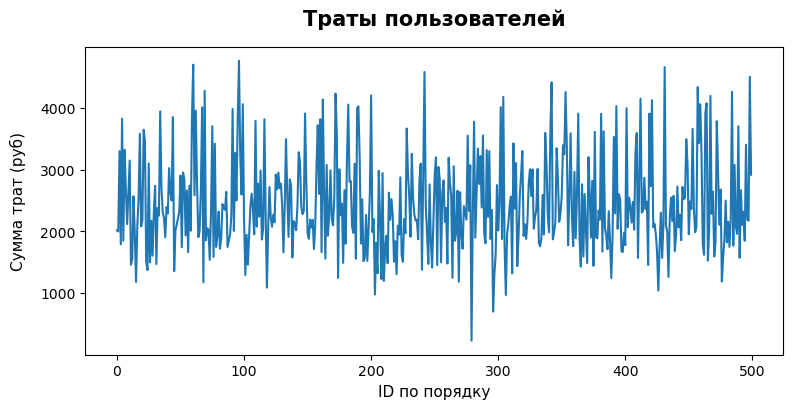

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(df.index, df['total spent'])

ax.set_title('Траты пользователей', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

#### Методы

- set_title — заголовок графика,
- set_xlabel — подпись горизонтальной оси,
- set_ylabel — подпись вертикальной оси.

#### Атрибуты

- fontsize — размер шрифта: число в пикселях или 'small', 'medium', 'large' (рекомендкется),
- fontweight — начертание по жирности: 'normal', 'bold', 'light',
- fontstyle — начертание по наклону: 'normal', 'italic',
- loc — положение надписи: 'left', 'center', 'right' для заголовка и горизонтальной подписи, 'bottom', 'center', 'top' для вертикальной подписи,
- pad — отступ заголовка от графика в пикселях,
- labelpad — отступ подписи от графика в пикселях,
- rotation — повород подписи в градусах,
- и т. д.

### Сетка

Сетка помогает глазу ориентироваться на графике. Она бывает особенно полезна, когда нужно быстро оценить значения на глаз — сетка даёт визуальные реперы.

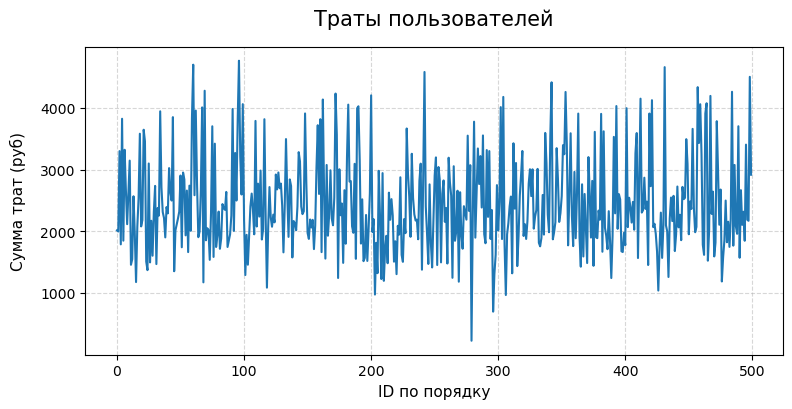

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(df.index, df['total spent'])

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

#### Метод
- grid — включает/отключает и настраивает сетку.

#### Атрибуты

- первый атрибут без названия — показать или скрыть: True, False,
- axis — по какой оси рисовать сетку: 'both', 'x', 'y',
- linewidth — толщина линии сетки в пикселях,
- linestyle — стиль линии: '-' (сплошная), '--' (пунктир), ':' (точки), '-.' (штрих-пунктир),
- alpha — прозрачность,
- и т. д.


### Метки по осям

Если по оси X 500 пользователей, подписывать каждого — бессмысленно: метки сольются в чёрную полосу. Тогда для меток нужно выбирать шаг и формат. А иногда бывает нужно заменять цифры на осмысленные названия (та еще возня).

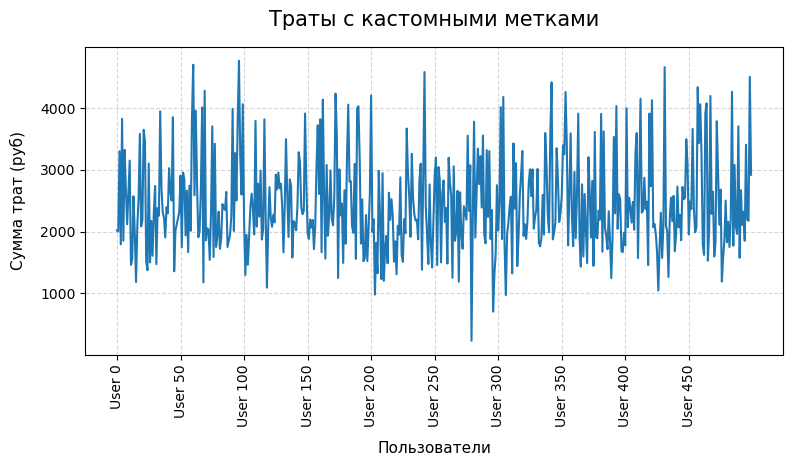

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(df.index, df['total spent'], color='C0')

step = 50
positions = df.index[::step]
labels = ['User ' + str(i) for i in positions]

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90)

ax.set_title('Траты с кастомными метками', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('Пользователи', fontsize=11, labelpad=10)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

#### Методы
- set_xticks(positions) — задаёт позиции на горизонтальной оси, на которых будут метки,
- set_xticklabels(labels) — задаёт текстовые подписи для этих позиций.

То же самое для оси Y: set_yticks, set_yticklabels.

#### Атрибуты

- первые атрибуты без названия — кастомно сформированные списки,
- и т. д.

### Легенда

Когда на графике несколько линий, без легенды невозможно понять, где control, где experiment. Легенда — это ключ к расшифровке цветов и стилей.

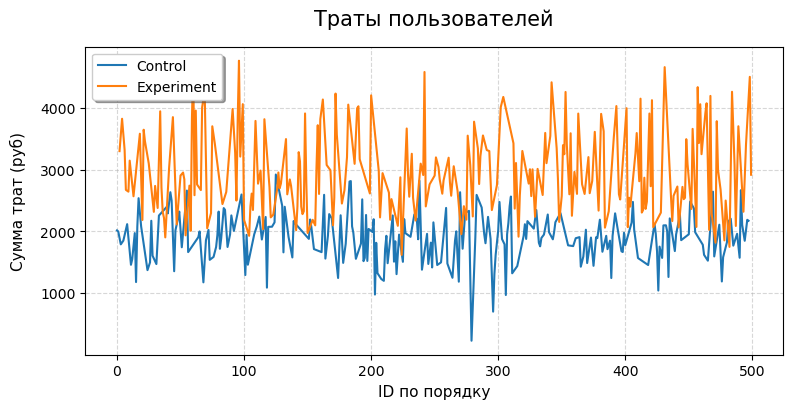

In [27]:
control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(control.index, control['total spent'], label='Control')
ax.plot(experiment.index, experiment['total spent'], label='Experiment')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

#### Метод

- legend — отображает легенду.

#### Атрибуты

- loc — положение легенды: 'upper left', 'upper right', 'lower left', 'lower right' или 'best' (подбирается автоматически),
- title — заголовок легенды,
- frameon — рамка вокруг легенды: True, False,
- shadow — тень: True,False,
- fancybox — скруглённые углы рамки: True, False,
- и т. д.


### Цвета и палитры

Цвета несут огромный смысл: control — синий, experiment — оранжевый. Хороший выбор цветов улучшает читаемость. Плохой — раздражает. В matplotlib'е есть несколько способов задания цвета:

- по имени — 'red', 'blue', 'green', 'orange', 'purple' и т. д. (именованных цветов несколько сотен),
- по hex-коду: это RGB в шестнадцатиричной системе (точно так же, как в HTML),
- по индексу палитры: 'C0', 'C1', …, 'C9' — 10 цветов цикла по умолчанию (рекомендуется).


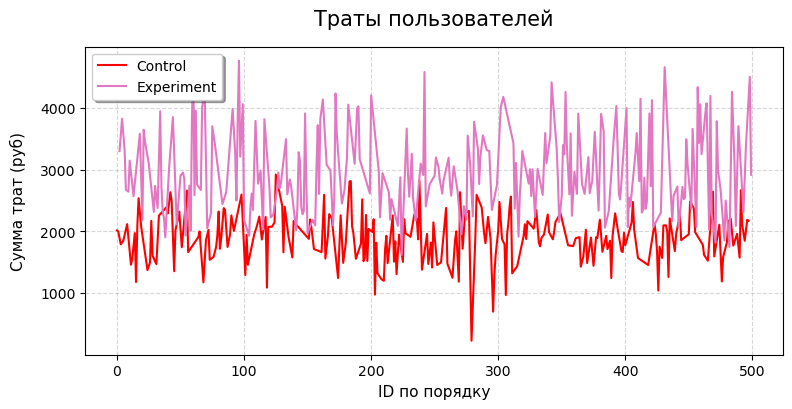

In [28]:
control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(control.index, control['total spent'], label='Control', color = 'red')
ax.plot(experiment.index, experiment['total spent'], label='Experiment', color = 'C6')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

#### О палитрах

Можно посмотреть RGB текущей палитры:

In [29]:
palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
palette

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

Или сменить палитру (это нужно делать в отдельной ячейке): 

In [30]:
plt.style.use('ggplot')

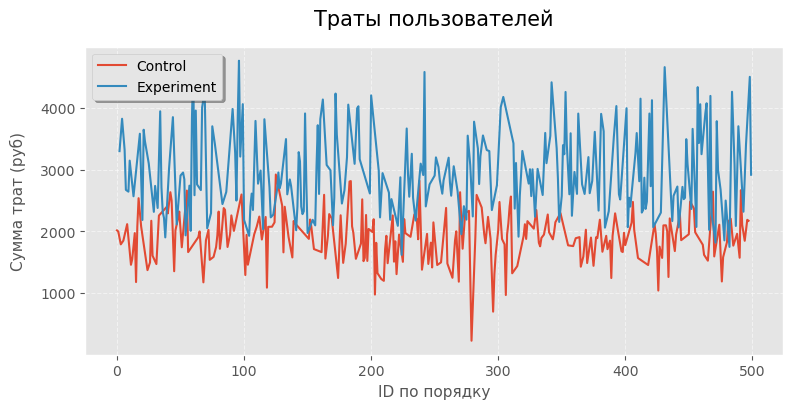

In [31]:
control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(control.index, control['total spent'], label='Control')
ax.plot(experiment.index, experiment['total spent'], label='Experiment')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

Правда, после этого абсолютно все графики в текущем ноутбуке будут отображаться в этой новой палитре:

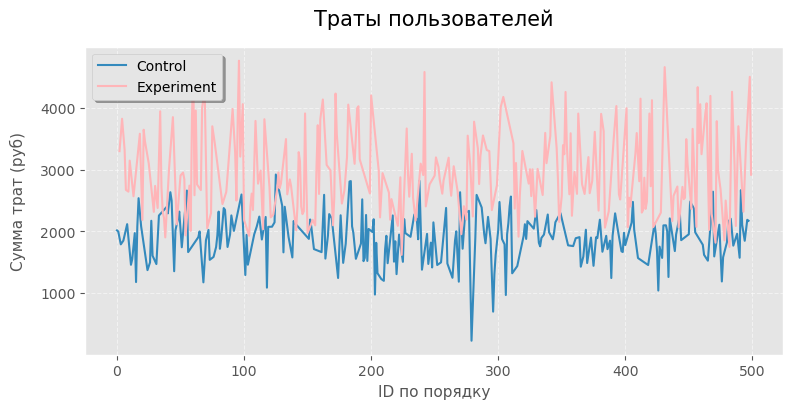

In [32]:
control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(control.index, control['total spent'], label='Control', color = 'C8')
ax.plot(experiment.index, experiment['total spent'], label='Experiment', color = 'C6')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

Чтобы сбросить matplotlib до заводских настроек, надо исполнить код (это тоже нужно  делать в отдельной ячейке):

In [33]:
plt.style.use('default')

Вот теперь все стало, как было раньше:

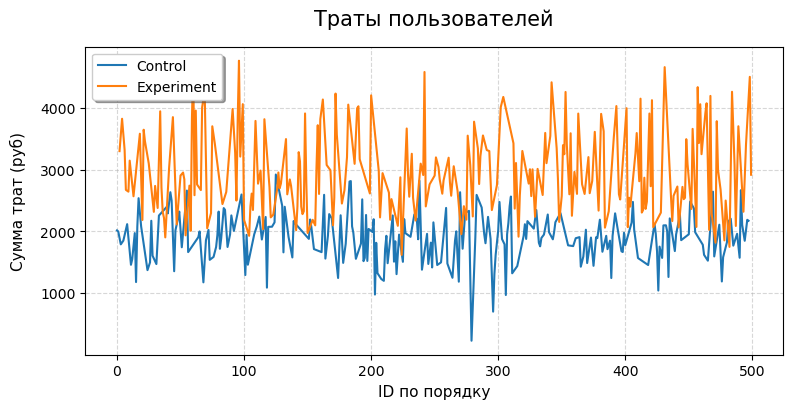

In [34]:
control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(control.index, control['total spent'], label='Control')
ax.plot(experiment.index, experiment['total spent'], label='Experiment')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.show()

#### Популярные палитры

В matplotlib доступно 26 встроенных палитр. Вот некоторые наиболее популярные из них:

- 'bmh' — спокойный, с тонкими линиями и светлым фоном (хорош для научных публикаций),
- 'grayscale' — полностью в оттенках серого (деален для печати на чёрно‑белом принтере),
- 'dark_background' — тёмный фон с контрастными цветами (удобен для презентаций и работы в темноте),
- 'ggplot' — повторяет эстетику популярного пакета ggplot2 для R (пастельные тона, светлая сетка).
- и т. д.

>#### Задание
Примените установки других палтир в коде  `plt.style.use()`. Только не забудьте их потом отменить.

### Выравнивание осей для нескольких графиков

Когда строишь несколько графиков рядом или друг под другом, оси должны быть согласованы. Иначе глаз прыгает, и сравнение становится невозможным. Атрибуты `sharex` и `sharey` метода `suplots` решают эту проблему.

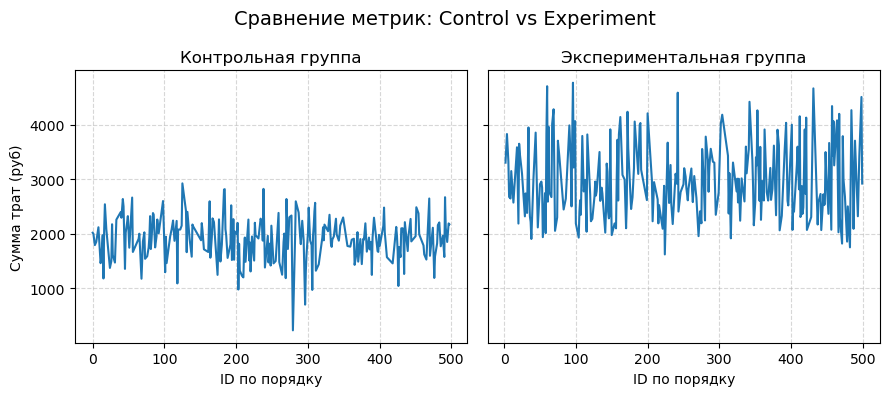

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharey=True)

control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].plot(control.index, control['total spent'])
ax[0].set_title('Контрольная группа')

ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].plot(experiment.index, experiment['total spent'])
ax[1].set_title('Экспериментальная группа')

ax[0].set_ylabel('Сумма трат (руб)')
ax[0].set_xlabel('ID по порядку')
ax[1].set_xlabel('ID по порядку')

fig.suptitle('Сравнение метрик: Control vs Experiment', fontsize=14, fontweight='light')

plt.tight_layout()
plt.show()

#### Методы
- suptitle — создает общий заголовок для всей группы графиков (применяется к объекту `figure`).
- tight_layout — автоматически подгоняет расстояния между графиками (бывает нужен, когда графиков много, и их метки наезжают друг на друга).

#### Атрибуты
- sharex — выравнивание меток горизонтальной оси,
- sharex — выравнивание меток вертикальной оси.

Оба атрибута выравнивания применяются к методу `subplots`.

>#### Задание
Постройте эти графики, выровняв их сверху вниз.

## § 4. Сохранение

Мы построили красивый график. Он сияет на экране. Но экран закроется, ноутбук выключится, и красота исчезнет. Чтобы этого не случилось, графики нужно сохранять. Куда и как? Если в научную статью — нужен высокий DPI (300–600), для веба — меньший (72–150), для презентации — 300, для печати в книгу — 300–1200. 

Универсальное значение — 300 DPI. Как говорил один знаменитый профессор, «всегда указываю 300, и ничего страшного не происходит». Мы будем придерживаться той же идеи. Потому что это золотая середина. Или, как говорили великие мыслители буддизма, практическое воплощение концепции срединного пути, который подразумевает избегания двух крайностей:
- потворства чувственным удовольствиям (гедонизм, жизнь ради наслаждений и сохранение графических файлов с избыточным разрешением),
- чрезмерного аскетизма (изнурение, самоистязание и файлы с разрешением 72).

Вот базовый синтаксис вывода графики во внешний файл:

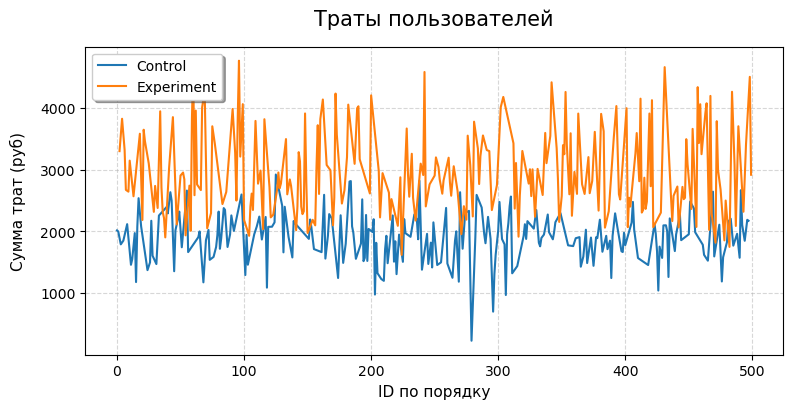

In [36]:
control = df[df['group'] == 'control']
experiment = df[df['group'] == 'experiment']

fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(True, linestyle='--', alpha=0.5)

ax.plot(control.index, control['total spent'], label='Control')
ax.plot(experiment.index, experiment['total spent'], label='Experiment')

ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

ax.set_title('Траты пользователей', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('ID по порядку', fontsize=11)
ax.set_ylabel('Сумма трат (руб)', fontsize=11, labelpad=10)

plt.savefig('pic/traits_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [37]:
control

,user id,group,device type,session count,pages per session,time on site total,purchase count,total spent,avg basket size,conversion,is returning,category preference
0,375,control,desktop,8,2.5,9.0,4,2017.78,504.45,0.500,True,clothing
1,100,control,desktop,5,7.3,31.5,8,1999.64,249.96,1.600,True,home
3,416,control,tablet,8,4.8,18.2,5,1791.64,358.33,0.625,False,electronics
5,477,control,desktop,6,4.4,33.0,2,1851.42,925.71,0.333,True,electronics
8,404,control,mobile,6,3.3,53.1,3,2118.35,706.12,0.500,False,clothing
...,...,...,...,...,...,...,...,...,...,...,...,...
491,14,control,mobile,8,2.5,23.0,2,2668.72,1334.36,0.250,False,clothing
492,337,control,mobile,6,5.0,28.8,4,2107.37,526.84,0.667,False,electronics
494,61,control,tablet,9,5.1,37.0,2,1849.61,924.80,0.222,True,electronics
496,352,control,tablet,10,3.8,12.4,4,2189.06,547.26,0.400,True,electronics


#### Метод

- savefig — сохраняет обект `figure` в файл.

#### Атрибуты
- fname (или первый атрибут без названия) — полное имя файла, вместе с указанием пути к нему (расширение определяет формат: .png, .jpg, .pdf, .svg, .eps),
- dpi — разрешение в точках на дюйм (для экрана — 72–150, для печати — 300 и выше, а впрочем, берите всегда 300, не ошибетесь),
- bbox_inches='tight' — обрезает белые поля по краям графика (без этого вокруг графика получается пустое пространство, которое потом приходится обрезать в редакторе).
- transparent — прозрачный фон: True, False (подходит для формата .png).

#### Форматы файлов: что и когда использовать

- .png — растровый формат без потерь, поддерживает прозрачность, маленький размер (отлично для веба, презентаций, отчётов),

- .jpg — растровый формат с потерями, не поддерживает прозрачность, маленький размер (для фотографий — хорошо, для графиков с тонкими линиями — не очень: артефакты сжатия могут испортить чёткие границы),

- .tiff — растровый формат без потерь, огромный размер (используется там, где нужна максимальная детализация — например, для публикации в Nature или Science, буржуи вообще, как правило, требуют .tiff),


- .svg — векторный формат, идеальный для веба: открывается в браузере, можно редактировать в Illustrator или Inkscape (в научных статьях используется крайне редко, редакции обычно просят растровые форматы),

- .eps — старый векторный формат (всё ещё используется в некоторых издательских системах, но потихоньку уходит в прошлое).


>#### Задание
Используя цикл по уникальным значениям признака `'device type'`, нарисуйте гистограммы распределений трат пользователей на разные девайсы. Выведите полученные гистограммы в файлы .png  с прозрачным фоном.

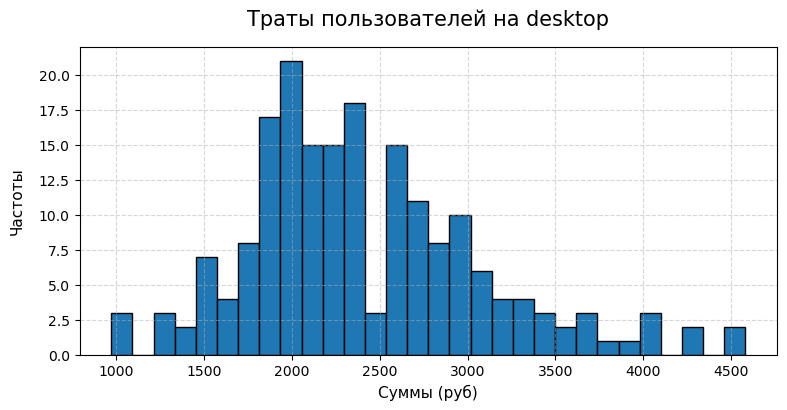

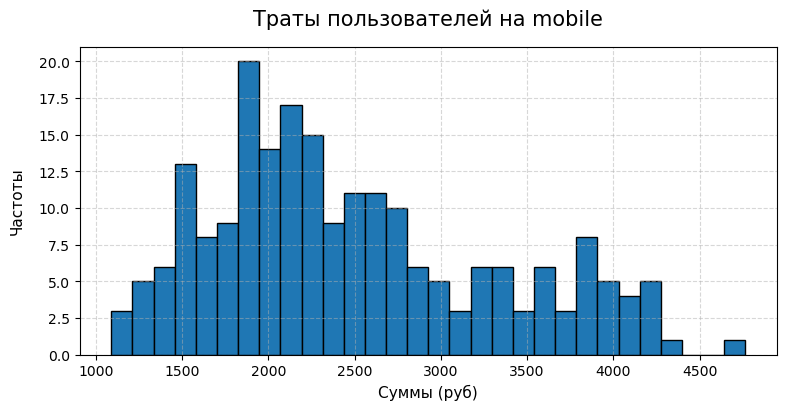

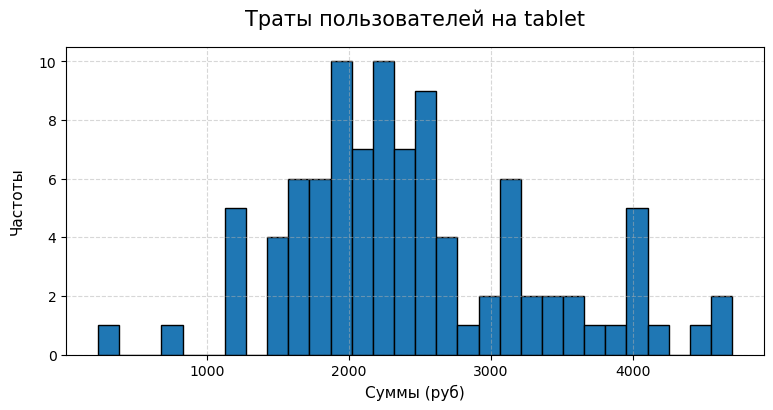

In [38]:
cols = df['device type'].unique()

for col in cols:
    
    d = df.loc[df['device type'] == col]
    
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.grid(True, linestyle='--', alpha=0.5)

    ax.hist(d['total spent'], bins=30, edgecolor='black')

    ax.set_title('Траты пользователей на ' + col, fontsize=15, fontweight='light', pad=15)
    ax.set_xlabel('Суммы (руб)', fontsize=11)
    ax.set_ylabel('Частоты', fontsize=11, labelpad=10)
    
    plt.savefig('pic/'+ col +'.png', dpi=300, bbox_inches='tight', transparent=True)
    
    plt.show()
    

## § 5. Визуализация как инструмент воздействия на аудиторию

Отвлечемся на минутку и зададим себе, казалось бы не имеющий отношения к нашей сегодняшней теме вопрос: для чего нужны группировки? Впоминаем предыдущие лекции и даем ответ — для того, чтобы скрыть детали. А для чего скрывать детали? — правильно: чтобы показать начальству. Начальник — тупой, если принести ему 15 чисел, он ничего не поймет и скажет: «Что ты мне принес? Убери эту писанину. Рузультат мне давай!». Но если принести ему две циферки, он поймет: «Вот одна циферка, а вот вторая. Первая меньше, а вторая больше. Ага. Понимаю». 

Мы занимаемся исследованиями, а на этапе исследования нам незачем прятать от самих себя детали своего же исследования (наоборот, нам нужны именно детали). Поэтому группировка — это для тупого начальника. А визуализация группировки — это для совсем тупого начальника, которому мы принесли даже не две циферки, а два столбика: один выше, а второй ниже. И начальник такой: «Два столбика: один выше, а второй ниже. Ага. Понимаю». А если мы ему пятнадцать столбиков принесем, он опять ничего не поймет.

Итак, запомним простое правило: **визуализация должна быть такой, чтобы ее понял идиот** (в медицинском смысле). Исключения составляют иллюстрации для научных статей и рабочие визуализации на этапе исслодования. Они могут быть сложными. Но если речь идет о публичной презентации или письменном отчете, выводы нужно вбивать в тупые мозги, не стесняясь показаться жестоким.

### Подготовка данных

Напомним, что данные, с которыми мы работаем на этой лекции, получились посте того, как мы провели A/B-тест для сравнения двух вариантов рекомендательной системы интернет-магазина, и бегло, не вдаваясь в глубокий анализ, посмотрели на результат. Сегодя мы вообще — пока еще не занимались анализом данных, мы просто рисовали картинки. Но за сухими цифрами — session count, total spent, conversion — стоят живые люди. Кто эти люди? Мужчины или женщины? Любят они наш магазин или терпеть не могут?

Чтобы ответить на эти вопросы, мы провели дополнительный телефонный опрос среди участников тестирования (да, мы позвонили 500 пользователям, и некоторые из них даже не бросили трубку). Мы получили две новые характеристики:

- gender — пол респондента (male / female),

- sentiment — его отношение к нашему интернет-магазину (positive / neutral / negative).

Теперь наша задача — объединить старые поведенческие данные с результатами опроса и посмотреть, как пол и отношение к магазину влияют на ключевые метрики. Это даст нам возможность глубже понять, почему экспериментальная группа показала лучшие результаты.

#### Конкатенация

Чтобы не испортить наш базовый датафрейм, сознаем его копию для конкатенации и в копии указываем в качестве индекса ID пользовтелей:

In [39]:
df_for_combine = df.copy()
df_for_combine.index = df_for_combine['user id']

Читаем датафрейм с результатами телефонного опроса и тоже заменяем индекс на ID:

In [40]:
df_new = pd.read_csv('data/df_survey.csv')
df_new.index = df_new['user id']

Конкатенируем по горизонтали, сбрасываем индекс и удаляем дублирующиеся столбцы:

In [41]:
combine = pd.concat([df_for_combine, df_new], axis=1, join='inner')
combine = combine.reset_index(drop=True)
combine = combine.T.drop_duplicates().T
combine

,user id,group,device type,session count,pages per session,time on site total,purchase count,total spent,avg basket size,conversion,is returning,category preference,gender,sentiment
0,375,control,desktop,8,2.5,9.0,4,2017.78,504.45,0.5,True,clothing,female,neutral
1,100,control,desktop,5,7.3,31.5,8,1999.64,249.96,1.6,True,home,female,negative
2,171,experiment,mobile,14,7.8,29.9,2,3301.23,1650.61,0.143,True,clothing,female,positive
3,416,control,tablet,8,4.8,18.2,5,1791.64,358.33,0.625,False,electronics,male,positive
4,236,experiment,mobile,13,6.4,48.0,7,3825.48,546.5,0.538,True,home,female,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,409,experiment,mobile,12,6.8,40.8,5,3406.47,681.29,0.417,True,clothing,female,positive
496,352,control,tablet,10,3.8,12.4,4,2189.06,547.26,0.4,True,electronics,male,neutral
497,257,control,mobile,6,6.2,15.0,3,2173.23,724.41,0.5,True,home,female,neutral
498,46,experiment,desktop,16,7.3,46.5,4,4504.24,1126.06,0.25,False,books,female,positive


Всё. Теперь у нас в руках — полный датасет. Пора извлекать инсайты и рисовать картинки для отчетов.

### Идея A. Кто приносит больше денег (mail или female)?

#### Гипотеза

Как было бы замечательно, думаем мы, если бы женщины в экспериментальной группе увеличили свои траты сильнее, чем мужчины. Если это так, то наша новая функциональность и новый дизайн особенно эффективны для женской аудитории. Мы покажем это начальнику, и ему понравится, так как он закоренелый сексит.

#### Группировка

Проводим группировку по гендеру и полу, и смотрим на результат:

In [42]:
instruction = {'total spent' : 'mean'}
gender_spending = combine.groupby(['group', 'gender']).agg(instruction)
gender_spending

total spent
group      gender             
control    female  1779.536240
           male    2029.037227
experiment female  3480.879764
           male    2466.065504

Четыре циферки. Четыре циферки — это много, конечно. Есть риск быть непонятыми. Но все-таки попробуем нарисовать картинку.

#### Визуализация

Первая строчка в группировке — это контрольная группа женщин: обозначим их CF. Вторая строчка — контрольная группа мужчин. Обозначим EM. Потом — экспериментальные женщины и экспериментальные мужчины. Обозначим их EF и EM соответственно.

И нарисуем наши заветные столбики:

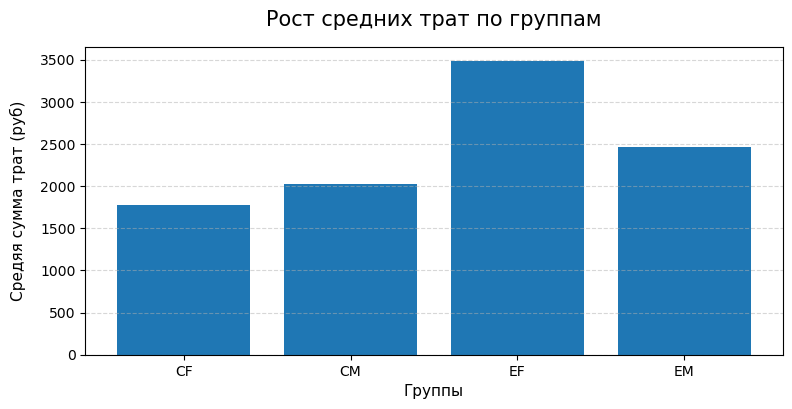

In [43]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar(['CF', 'CM', 'EF', 'EM'], gender_spending['total spent'], color = ['C0', 'C0', 'C0', 'C0'])

ax.set_title('Рост средних трат по группам', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('Группы', fontsize=11)
ax.set_ylabel('Средяя сумма трат (руб)', fontsize=11, labelpad=10)
    
plt.show()

В принципе, нормальная картинка. Только скорее всего мы все-таки услышим скарментальное: «Что это? Где результат?». Хотя нам-то результат очевиден: женщины в экспериментальной группе начали тратить в два раза больше, а мужчины — тоже больше но не на столько.

Думаем дальше.

#### Вторая версия визуализации

Нужно раскрасить нашу картинку, думаем мы. Потому что начальству нравятся цветные картинки. И мы красим женщин в желтый цвет (примерно так же, как поступал когда-то Ван Гог):

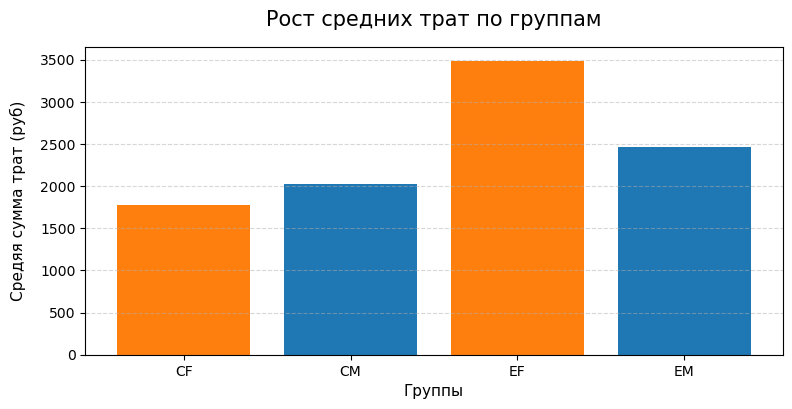

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar(['CF', 'CM', 'EF', 'EM'], gender_spending['total spent'], color = ['C1', 'C0', 'C1', 'C0'])

ax.set_title('Рост средних трат по группам', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('Группы', fontsize=11)
ax.set_ylabel('Средяя сумма трат (руб)', fontsize=11, labelpad=10)
    
plt.show()

Стало лучше. По крайней мере сразу видно, что желтые столбики растут сильнее, чем синие. 

Но хочется их выстроить в другом порядке: пусть сначала идут синие столбики (был маленький, а потом немного подрос), а затем — желтые (был маленький, а потом как вырастет!). Да. Так будет еще лучше. Погнали.

#### Третья версия визуализации

Но как их передвинуть? Они же идут в том порядке, в котором следуют строки в группировке? Ответ напрашивается: нужно изменить порядок следования строк. Напрягаем память и вспоминаем, что это мы умеем:

In [45]:
gender_spending = gender_spending.iloc[[1, 3, 0, 2]]
gender_spending

,,total spent
group,gender,
control,male,2029.037227
experiment,male,2466.065504
control,female,1779.536240
experiment,female,3480.879764


Переобозначаем метки горизонтальной оси (они теперь идут в другом порядке) и указываем нужные цвета на  нужных позициях:

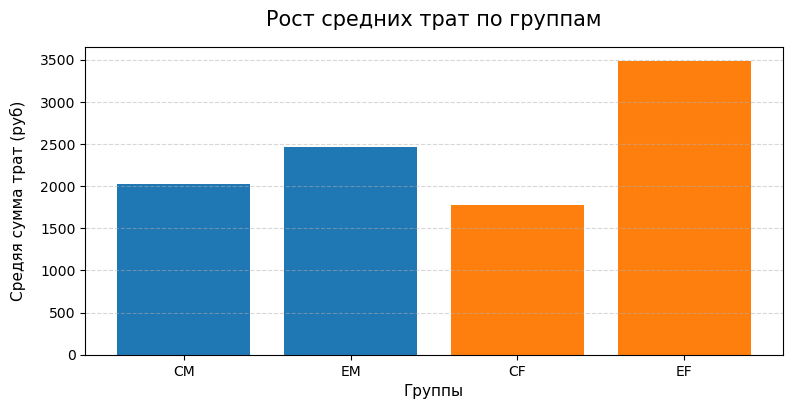

In [46]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.bar(['CM', 'EM', 'CF', 'EF'], gender_spending['total spent'], color = ['C0', 'C0', 'C1', 'C1'])

ax.set_title('Рост средних трат по группам', fontsize=15, fontweight='light', pad=15)
ax.set_xlabel('Группы', fontsize=11)
ax.set_ylabel('Средяя сумма трат (руб)', fontsize=11, labelpad=10)
    
plt.show()

#### Четвертая версия визуализации

Попробуем развести картинки по двум разным координатным осям:

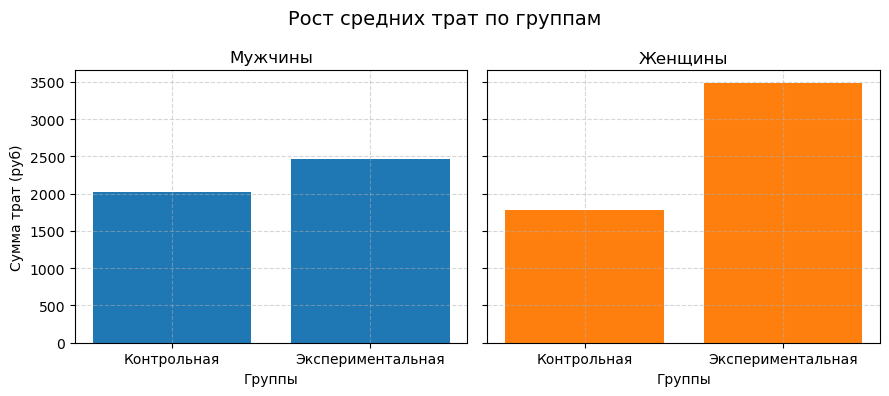

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4), sharey=True)

ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].bar(['Контрольная', 'Экспериментальная'], gender_spending.iloc[[0,1]]['total spent'], color = ['C0', 'C0'])
ax[0].set_title('Мужчины')

ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].bar(['Контрольная', 'Экспериментальная'], gender_spending.iloc[[2,3]]['total spent'], color = ['C1', 'C1'])
ax[1].set_title('Женщины')

ax[0].set_ylabel('Сумма трат (руб)')
ax[0].set_xlabel('Группы')
ax[1].set_xlabel('Группы')

fig.suptitle('Рост средних трат по группам', fontsize=14, fontweight='light')

plt.tight_layout()
plt.show()

И вот только теперь наша визуализация того, что было нам давным-давно понятно (у женщин колоссальный рост, у мужчин все гогаздо скромнее), стала вполне очевидной. Вряд ли в ней хоть кто-то сможет запутаться. Хотя, кто знает.

## Домашнее задание

Вам нужно продолжить исследование этого датасета: проверить гипотезы B, C, и D и визуализировать результаты.

### Идея B. Лояльность и кошелек 

- Здесь не нужна группировка. Локализуемся по `sentiment` и смотрим распределение `conversion`.

- Рисуем три «ящика с усами» (Positive, Neutral, Negative).

- Действительно ли люди с негативным отношением тратят меньше? Или они «плачут, колются, но продолжают жрать кактус» (покупать у нас)?

### Идея C. Счастье в группах

- Группируем по `group` (без `gender`) и агрегируем `sentiment` при помощи `count`.
- Рисуем столбики, применяя тоже метод, что и в §5 (`bar`).
- Изменилось ли отношение людей к магазину в экспериментальной группе? Может, мы заработали больше денег, но люди стали злее из-за того, что мы их «заставили» покупать агрессивным маркетингом?

### Идея D. Технологические предпочтения полов 

- Группируем по `gender` и `device type`.
- Рисуем две серии столбиков (для мужчин и для женщин).
- Смотрим, на чем сидят женщины, а на чем мужчины. Это поможет понять, под какой девайс в первую очередь оптимизировать дизайн для конкретной аудитории.